In [5]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import SimpleITK as sitk

import os

In [6]:
img_itk = sitk.ReadImage('/workspace/Personalized-FS/data/QUBIQ/validation_data_qubiq2021_QC/brain-growth/Validation/case39/image.nii.gz')
img = sitk.GetArrayFromImage(img_itk).astype(np.float32)  # [Z,Y,X]

In [7]:
img.shape

(256, 256)

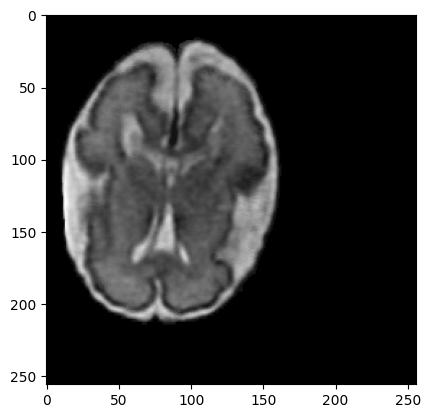

In [8]:
plt.imshow(img, cmap = 'gray')

In [25]:
npzfile0 = np.load('/workspace/Personalized-FS/vis2/00_1_2_case_1_z0.npz')
npzfile1 = np.load('/workspace/Personalized-FS/vis2/01_1_2_case_1_z0.npz')

In [11]:
print(npzfile1.files)

['sup_img_part', 'sup_fgm_part', 'sup_bgm_part', 'query_images', 'query_labels', 'labels', 'n_scan', 'pred']


In [12]:
for k in npzfile0.files:
    print(k, npzfile0[k].shape, npzfile0[k].dtype)

sup_img_part (1, 3, 256, 256) float32
sup_fgm_part (7, 1, 256, 256) float32
sup_bgm_part (7, 1, 256, 256) float32
query_images (1, 3, 256, 256) float32
query_labels (7, 1, 256, 256) float32
labels (1,) int64
n_scan () int64
pred (7, 256, 256) int64


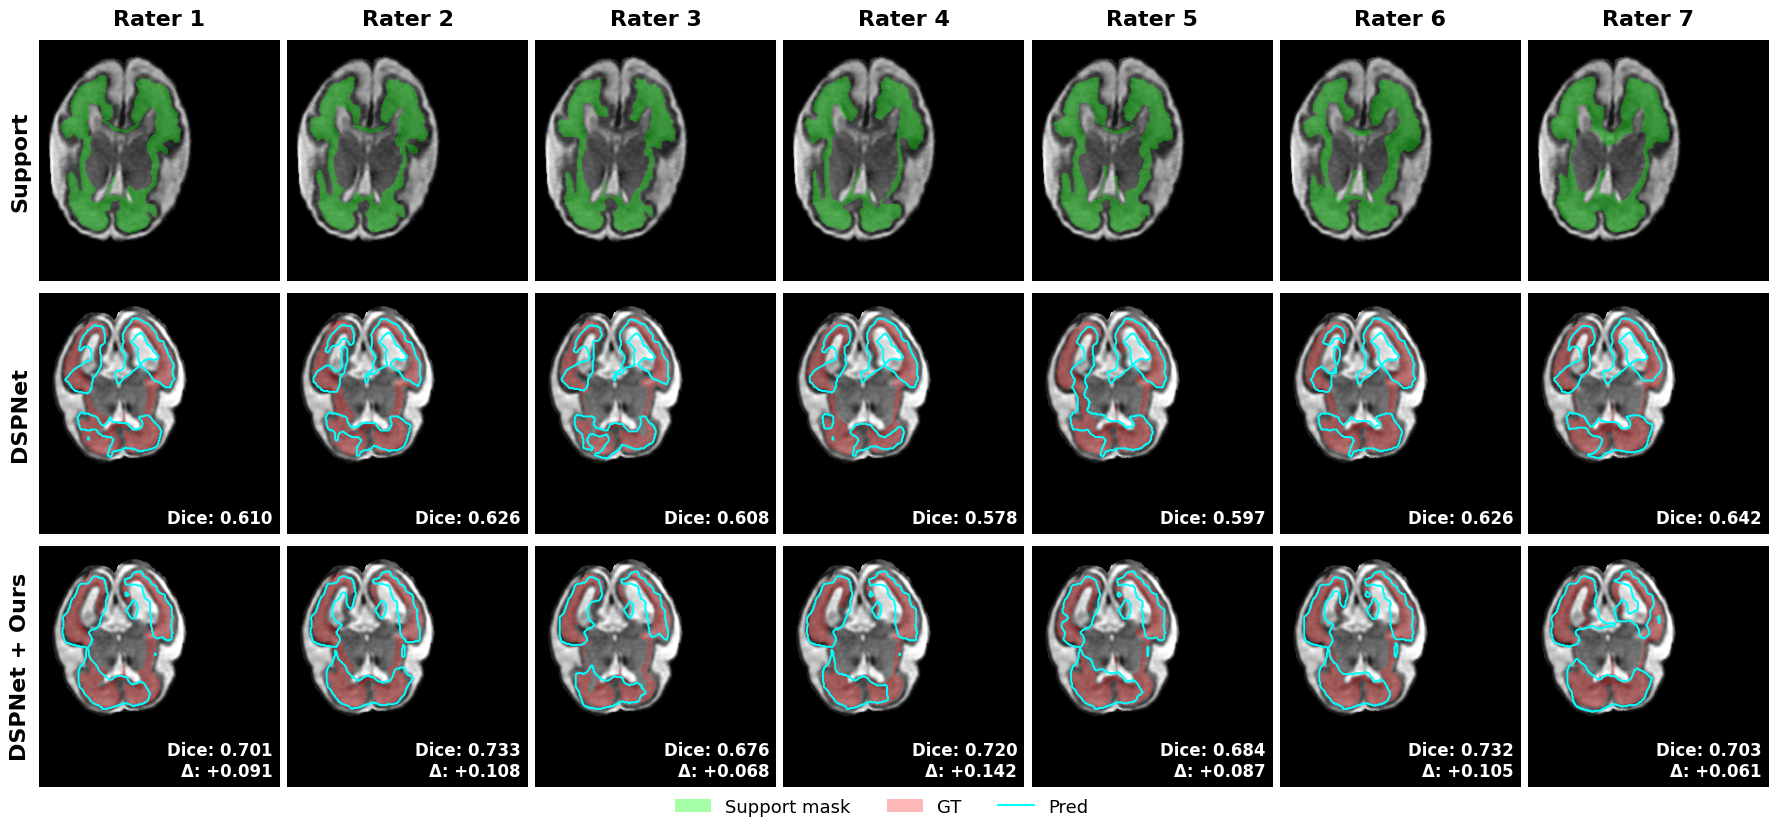

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from pathlib import Path
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

base_dir = Path("/workspace/Personalized-FS/data/QUBIQ/validation_data_qubiq2021_QC/brain-growth/Validation/case39")
img_path = base_dir / "image.nii.gz"

def norm01(x):
    x = x.astype(np.float32)
    x_min, x_max = x.min(), x.max()
    if x_max > x_min:
        x = (x - x_min) / (x_max - x_min)
    else:
        x = np.zeros_like(x, dtype=np.float32)
    return x

def dice_score(a, b):
    a = a.astype(bool)
    b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    denom = a.sum() + b.sum()
    if denom == 0:
        return 1.0
    return 2.0 * inter / denom

def get_center_channel(x):
    if x.ndim == 3 and x.shape[0] == 3:
        return x[1]
    return x

def overlay_mask(ax, image, mask, mask_color=(0, 1, 0), alpha=0.35):
    image = norm01(image)
    ax.imshow(image, cmap="gray")

    mask = mask.astype(bool)
    colored = np.zeros((*mask.shape, 4), dtype=np.float32)
    colored[..., 0] = mask_color[0]
    colored[..., 1] = mask_color[1]
    colored[..., 2] = mask_color[2]
    colored[..., 3] = mask.astype(np.float32) * alpha
    ax.imshow(colored)

    ax.axis("off")

def overlay_gt_pred(ax, image, gt, pred, text=None):
    image = norm01(image)
    gt = gt.astype(bool)
    pred = pred.astype(bool)

    ax.imshow(image, cmap="gray")

    gt_rgba = np.zeros((*gt.shape, 4), dtype=np.float32)
    gt_rgba[..., 0] = 1.0
    gt_rgba[..., 3] = gt.astype(np.float32) * 0.28
    ax.imshow(gt_rgba)

    if pred.any():
        ax.contour(pred.astype(np.uint8), levels=[0.5], colors=["cyan"], linewidths=1.4)

    if text is not None:
        ax.text(
            0.97, 0.03, text,
            transform=ax.transAxes,
            ha="right", va="bottom",
            color="white", fontsize=12, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="black", alpha=0.70, edgecolor="none")
        )

    ax.axis("off")


# ----- Row 1: support image + 7 support masks -----
img_itk = sitk.ReadImage(str(img_path))
img_vol = sitk.GetArrayFromImage(img_itk)  # (Z, H, W)

support_slice = img_vol

support_masks = []
for r in range(1, 8):
    mask_path = base_dir / f"task01_seg{r:02d}.nii.gz"
    mask_vol = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_path)))
    support_masks.append(mask_vol > 0)
support_masks = np.stack(support_masks, axis=0)  # (7, H, W)

# ----- Row 2: npzfile1 -----
qimg1 = get_center_channel(npzfile1["query_images"][0])   # (H, W)
qlab1 = npzfile1["query_labels"][:, 0] > 0                # (7, H, W)
pred1 = npzfile1["pred"] > 0                              # (7, H, W)

# ----- Row 3: npzfile0 -----
qimg0 = get_center_channel(npzfile0["query_images"][0])   # (H, W)
qlab0 = npzfile0["query_labels"][:, 0] > 0                # (7, H, W)
pred0 = npzfile0["pred"] > 0                              # (7, H, W)

# ----- Plot -----
fig, axes = plt.subplots(3, 7, figsize=(18, 9))

for j in range(7):
    overlay_mask(
        axes[0, j],
        support_slice,
        support_masks[j],
        mask_color=(0, 1, 0),
        alpha=0.35
    )

    d1 = dice_score(pred1[j], qlab1[j])
    overlay_gt_pred(
        axes[1, j],
        qimg1,
        qlab1[j],
        pred1[j],
        text=f"Dice: {d1:.3f}"
    )

    d0 = dice_score(pred0[j], qlab0[j])
    delta = d0 - d1
    overlay_gt_pred(
        axes[2, j],
        qimg0,
        qlab0[j],
        pred0[j],
        text=f"Dice: {d0:.3f}\nΔ: {delta:+.3f}"
    )

plt.subplots_adjust(
    left=0.03, right=0.995,
    top=0.93, bottom=0.10,
    wspace=0, hspace=0.05
)

for j in range(7):
    pos = axes[0, j].get_position()
    x = (pos.x0 + pos.x1) / 2
    y = pos.y1 + 0.012
    fig.text(
        x, y, f"Rater {j+1}",
        ha="center", va="bottom",
        fontsize=16, fontweight="bold"
    )

row_labels = ["Support", "DSPNet", "DSPNet + Ours"]
for i, label in enumerate(row_labels):
    pos = axes[i, 0].get_position()
    x = pos.x0 - 0.005
    y = (pos.y0 + pos.y1) / 2
    fig.text(
        x, y, label,
        ha="right", va="center",
        fontsize=16, fontweight="bold", rotation=90
    )
    
legend_handles = [
    Patch(facecolor=(0, 1, 0), edgecolor="none", alpha=0.35, label="Support mask"),
    Patch(facecolor="red", edgecolor="none", alpha=0.28, label="GT"),
    Line2D([0], [0], color="cyan", lw=1.4, label="Pred")
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=3,
    frameon=False,
    fontsize=13
)

plt.savefig("qualitative2.pdf", bbox_inches="tight")
plt.show()